# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download the Diabetes Risk Dataset](https://www.kaggle.com/datasets/mansiaggarwal88/diabetes-risk-prediction)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

/kaggle/input/datasets/mansiaggarwal88/diabetes-risk-prediction/generate_dataset.py
/kaggle/input/datasets/mansiaggarwal88/diabetes-risk-prediction/diabetes_risk.csv


## Import CSV And convert to DataFrame

In [71]:
df = pd.read_csv('diabetes_risk.csv')

# Preprocessing

## Frist five row

In [72]:
df.head()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


## last Five row

In [73]:
df.tail()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
14995,14996,47,Male,Mumbai,37.7,No,Sedentary,Non-Vegetarian,Never,Never,6.8,7,213,8.1,150,100,141.7,High,High
14996,14997,48,Female,Mumbai,20.6,No,Moderate,Non-Vegetarian,Never,NaN,6.0,8,162,6.5,132,80,91.0,NaN,Low
14997,14998,34,Female,Nagpur,17.9,No,Active,Vegetarian,Never,Never,7.0,6,137,6.5,136,90,88.8,Low,Low
14998,14999,56,Male,Ahmedabad,20.7,Yes,Active,Vegetarian,Never,Never,6.0,5,163,6.9,140,87,94.8,Low,Low
14999,15000,54,Male,Surat,34.5,No,Moderate,Vegetarian,Never,Never,7.4,2,186,7.2,150,88,130.4,Middle,Moderate


## Shape of our dataset

In [74]:
df.shape

(15000, 19)

## List out all columns

In [75]:
df.columns

Index(['patient_id', 'age', 'gender', 'city', 'bmi', 'family_history_diabetes',
       'physical_activity_level', 'diet_type', 'smoking_status',
       'alcohol_consumption', 'hours_sleep_per_night', 'stress_level',
       'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic',
       'blood_pressure_diastolic', 'waist_circumference_cm', 'income_bracket',
       'diabetes_risk'],
      dtype='object')

## Datatype of each columns

In [76]:
df.dtypes

patient_id                    int64
age                           int64
gender                       object
city                         object
bmi                         float64
family_history_diabetes      object
physical_activity_level      object
diet_type                    object
smoking_status               object
alcohol_consumption          object
hours_sleep_per_night       float64
stress_level                  int64
fasting_blood_sugar           int64
hba1c_level                 float64
blood_pressure_systolic       int64
blood_pressure_diastolic      int64
waist_circumference_cm      float64
income_bracket               object
diabetes_risk                object
dtype: object

## Information of all Columns

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            14528 non-null  object 
 9   alcohol_consumption       11212 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

## Check Null Value

In [78]:
df.isnull().sum()

patient_id                     0
age                            0
gender                         0
city                           0
bmi                            0
family_history_diabetes        0
physical_activity_level        0
diet_type                      0
smoking_status               472
alcohol_consumption         3788
hours_sleep_per_night          0
stress_level                   0
fasting_blood_sugar            0
hba1c_level                    0
blood_pressure_systolic        0
blood_pressure_diastolic       0
waist_circumference_cm         0
income_bracket               463
diabetes_risk                  0
dtype: int64

## Drop Null Features

In [79]:
df.drop(columns=['smoking_status', 'alcohol_consumption', 'income_bracket'], inplace=True)

## Check Dupicate Value

In [80]:
df.duplicated().sum()

np.int64(0)

## Summary

In [81]:
df.describe()

,patient_id,age,bmi,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,44.333667,23.062260,7.309860,5.941200,168.789933,6.878387,139.496200,86.256933,100.207933
std,4330.271354,10.383753,4.046391,1.109372,2.148406,38.365822,0.843276,12.660785,8.386529,10.760331
min,1.000000,18.000000,15.000000,3.000000,1.000000,72.000000,4.800000,80.000000,50.000000,73.200000
25%,3750.750000,38.000000,20.100000,6.700000,4.000000,145.000000,6.300000,130.000000,80.000000,92.500000
50%,7500.500000,45.000000,22.700000,7.000000,6.000000,165.000000,6.800000,140.000000,88.000000,99.300000
75%,11250.250000,52.000000,25.600000,8.000000,7.000000,189.000000,7.300000,150.000000,90.000000,106.900000
max,15000.000000,80.000000,40.800000,12.000000,10.000000,400.000000,13.400000,200.000000,120.000000,148.200000


# EDA

In [82]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

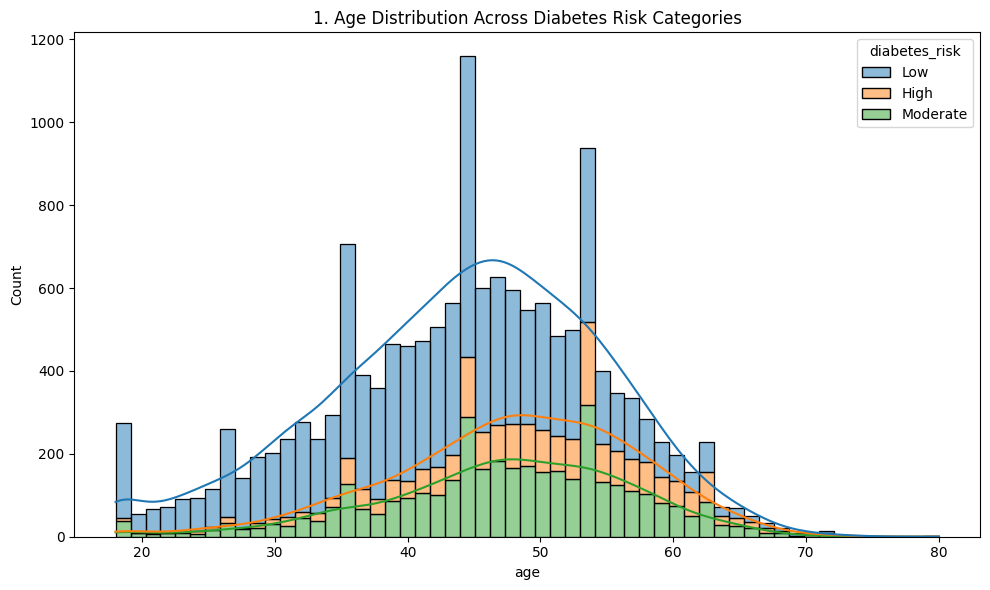

In [83]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='age', hue='diabetes_risk', kde=True, multiple='stack')
plt.title(f'{plot_no}. Age Distribution Across Diabetes Risk Categories')
show_fig()
plot_no += 1

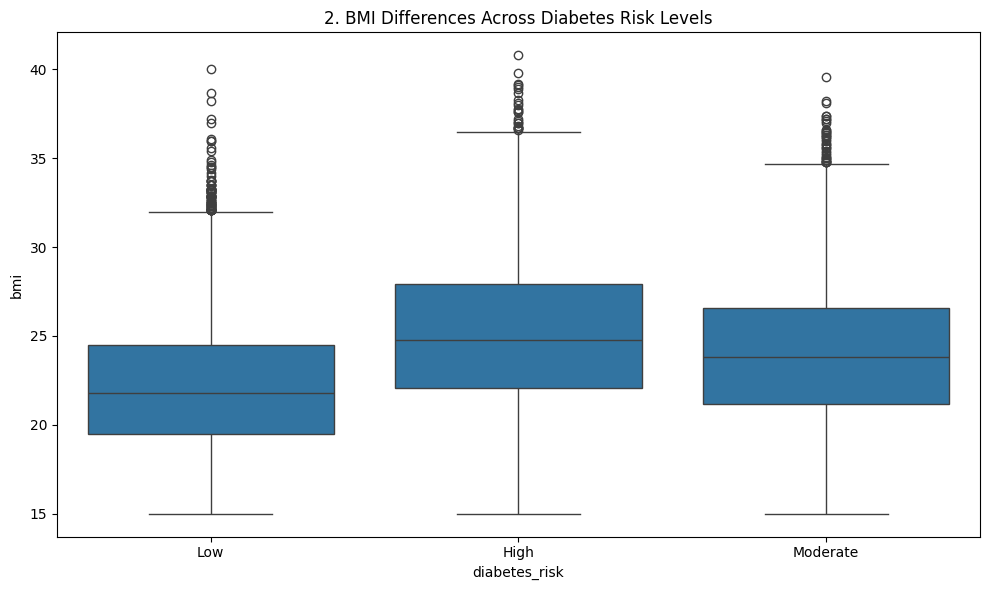

In [84]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='diabetes_risk', y='bmi')
plt.title(f'{plot_no}. BMI Differences Across Diabetes Risk Levels')
show_fig()
plot_no += 1

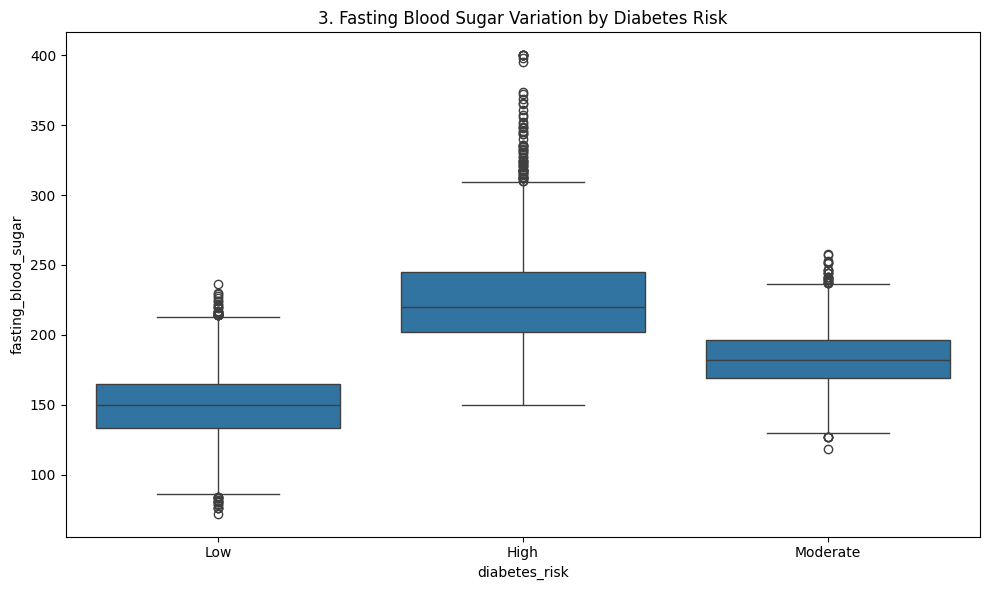

In [85]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='diabetes_risk', y='fasting_blood_sugar')
plt.title(f'{plot_no}. Fasting Blood Sugar Variation by Diabetes Risk')
show_fig()
plot_no += 1

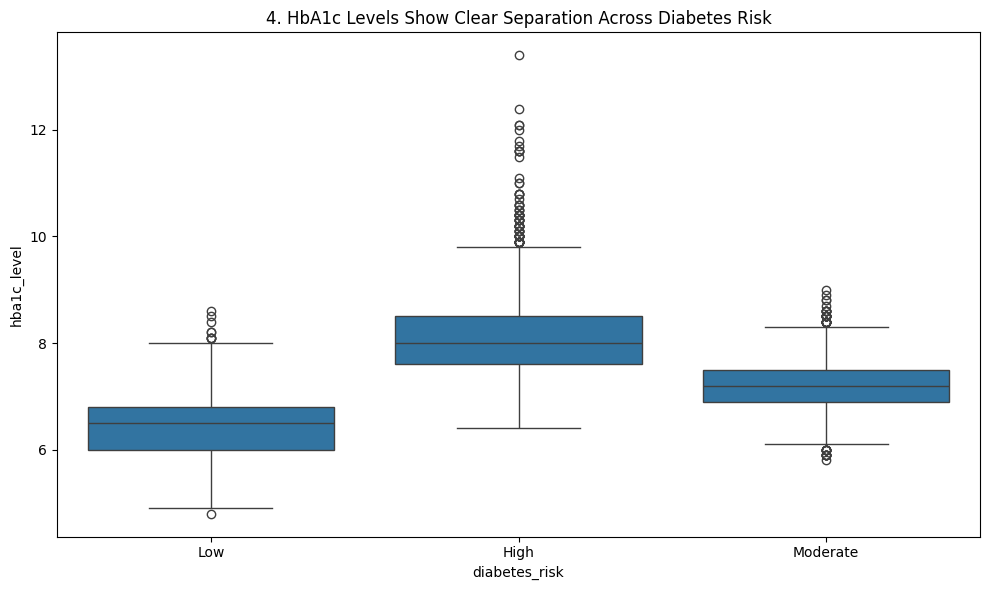

In [86]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='diabetes_risk', y='hba1c_level')
plt.title(f'{plot_no}. HbA1c Levels Show Clear Separation Across Diabetes Risk')
show_fig()
plot_no += 1

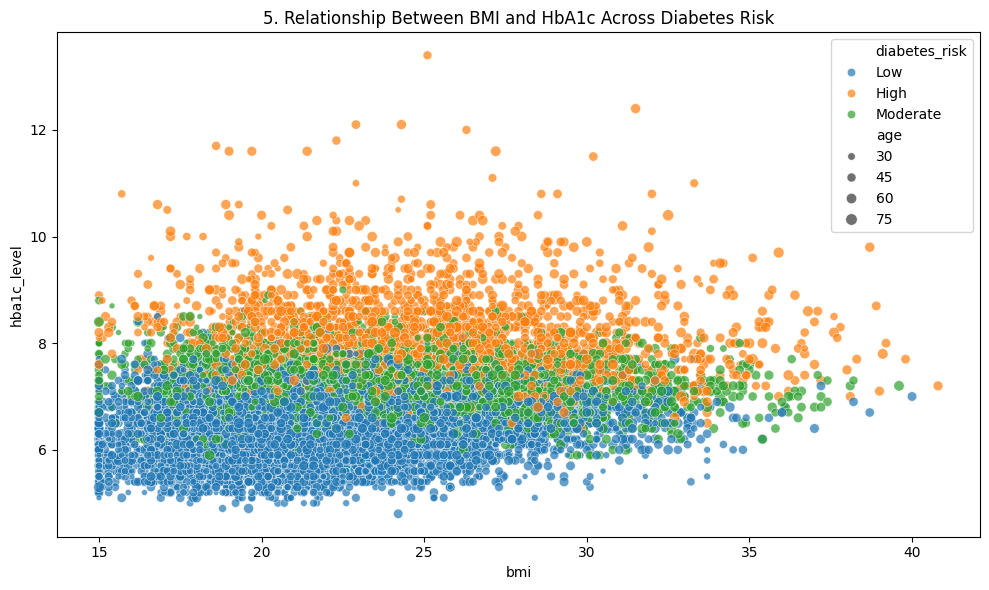

In [87]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='bmi', y='hba1c_level', hue='diabetes_risk', size='age', alpha=0.7)
plt.title(f'{plot_no}. Relationship Between BMI and HbA1c Across Diabetes Risk')
show_fig()
plot_no += 1

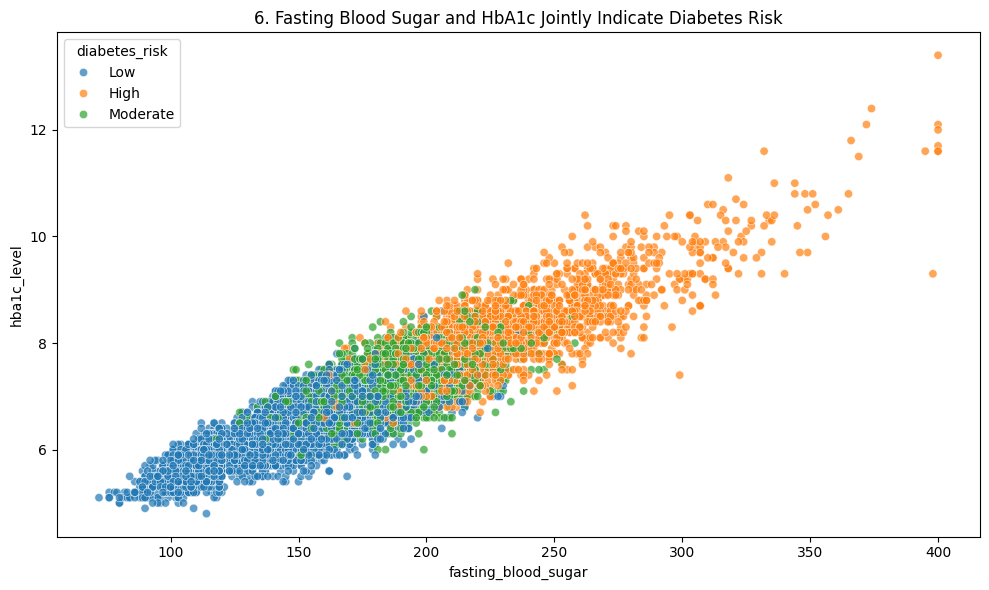

In [88]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='fasting_blood_sugar', y='hba1c_level', hue='diabetes_risk', alpha=0.7)
plt.title(f'{plot_no}. Fasting Blood Sugar and HbA1c Jointly Indicate Diabetes Risk')
show_fig()
plot_no += 1

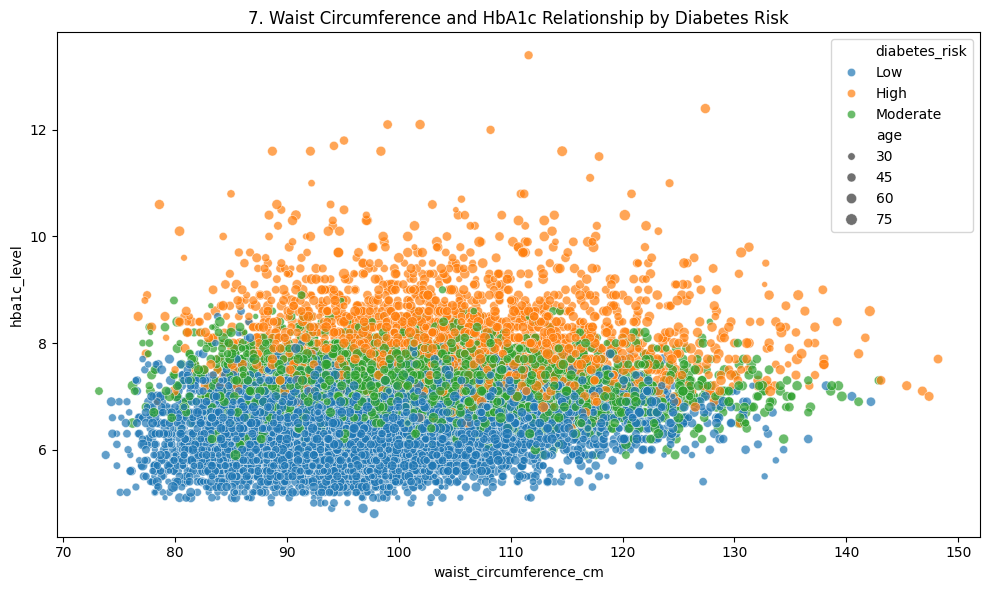

In [89]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='waist_circumference_cm', y='hba1c_level', hue='diabetes_risk', size='age', alpha=0.7)
plt.title(f'{plot_no}. Waist Circumference and HbA1c Relationship by Diabetes Risk')
show_fig()
plot_no += 1

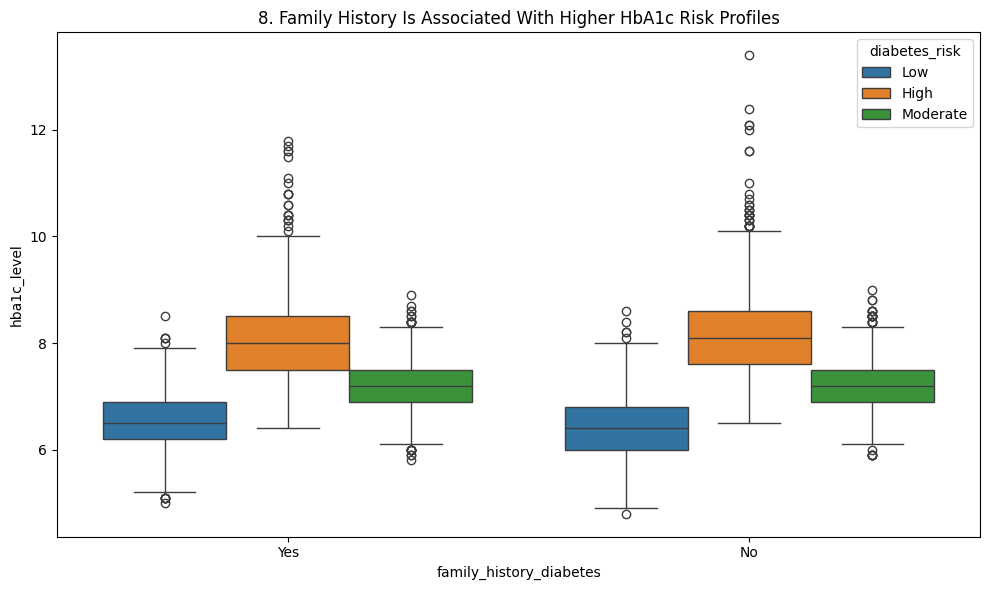

In [90]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='family_history_diabetes', y='hba1c_level', hue='diabetes_risk')
plt.title(f'{plot_no}. Family History Is Associated With Higher HbA1c Risk Profiles')
show_fig()
plot_no += 1

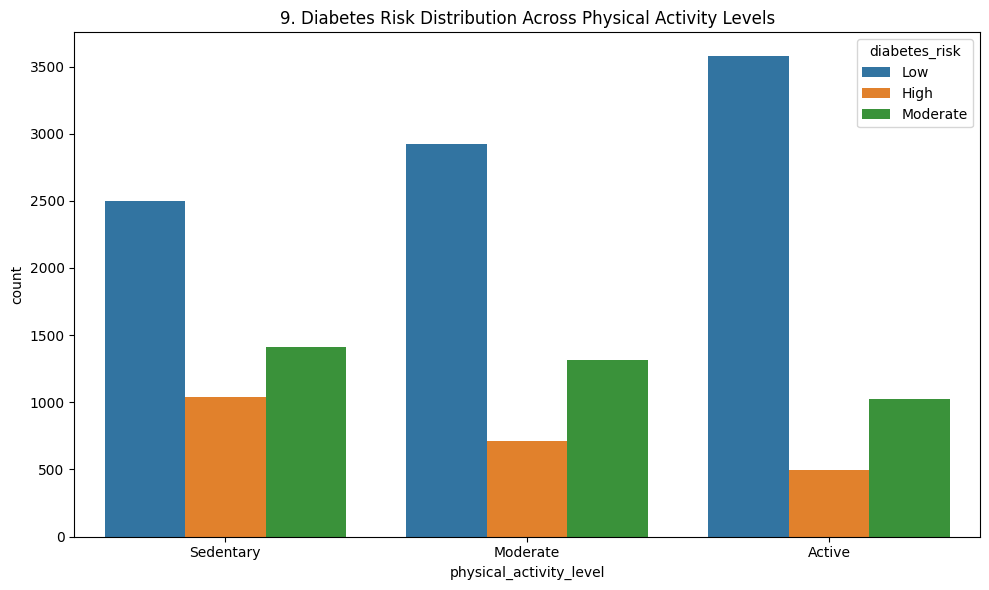

In [91]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='physical_activity_level', hue='diabetes_risk')
plt.title(f'{plot_no}. Diabetes Risk Distribution Across Physical Activity Levels')
show_fig()
plot_no += 1

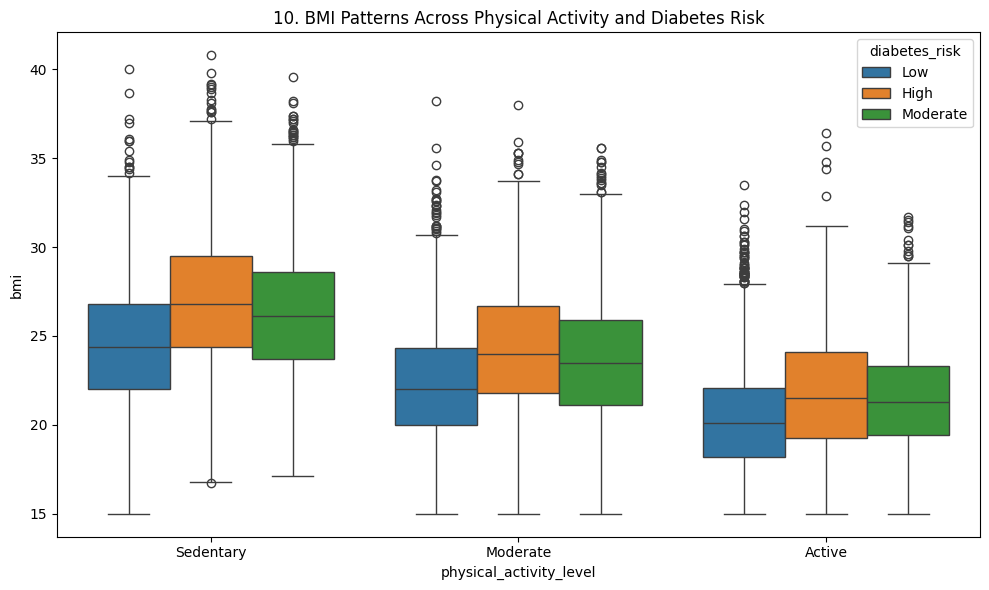

In [92]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='physical_activity_level', y='bmi', hue='diabetes_risk')
plt.title(f'{plot_no}. BMI Patterns Across Physical Activity and Diabetes Risk')
show_fig()
plot_no += 1

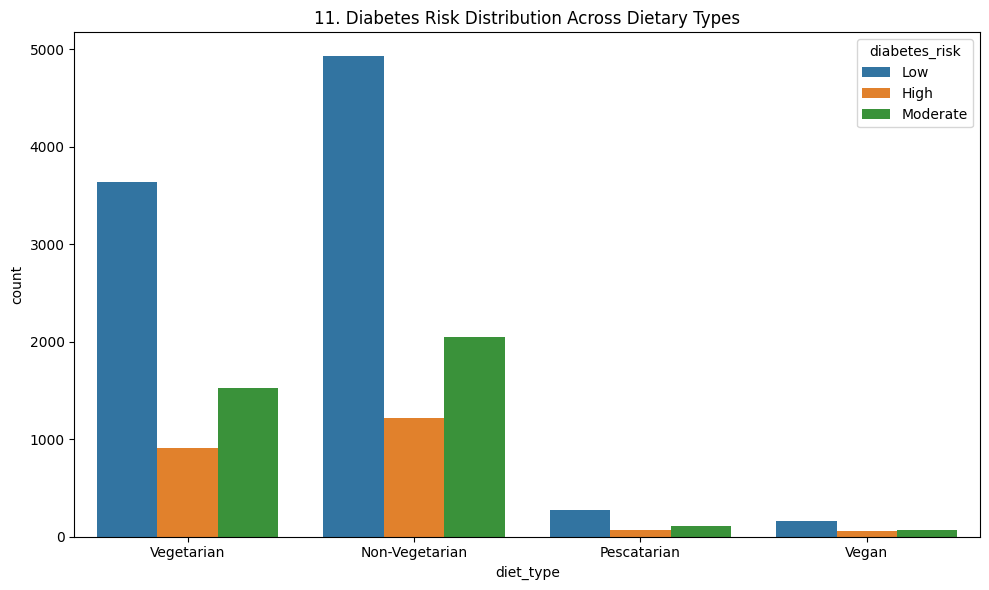

In [93]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='diet_type', hue='diabetes_risk')
plt.title(f'{plot_no}. Diabetes Risk Distribution Across Dietary Types')
show_fig()
plot_no += 1

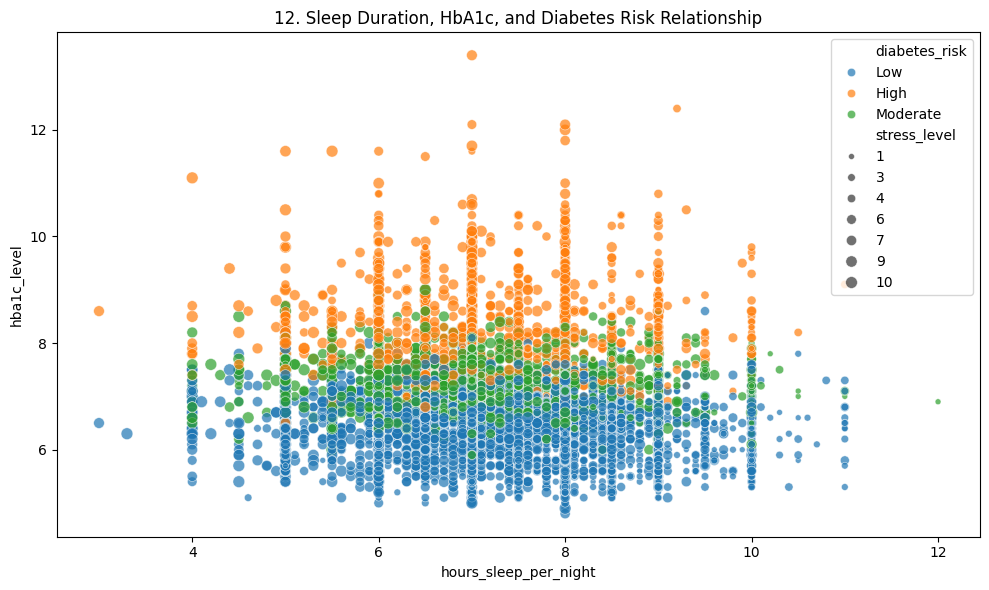

In [94]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='hours_sleep_per_night', y='hba1c_level', hue='diabetes_risk', size='stress_level', alpha=0.7)
plt.title(f'{plot_no}. Sleep Duration, HbA1c, and Diabetes Risk Relationship')
show_fig()
plot_no += 1

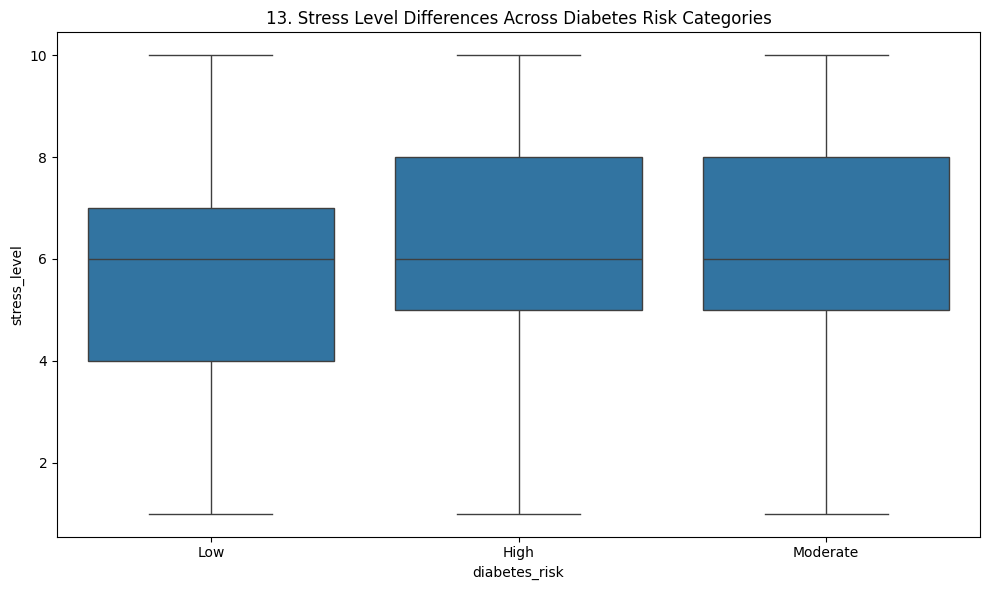

In [95]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='diabetes_risk', y='stress_level')
plt.title(f'{plot_no}. Stress Level Differences Across Diabetes Risk Categories')
show_fig()
plot_no += 1

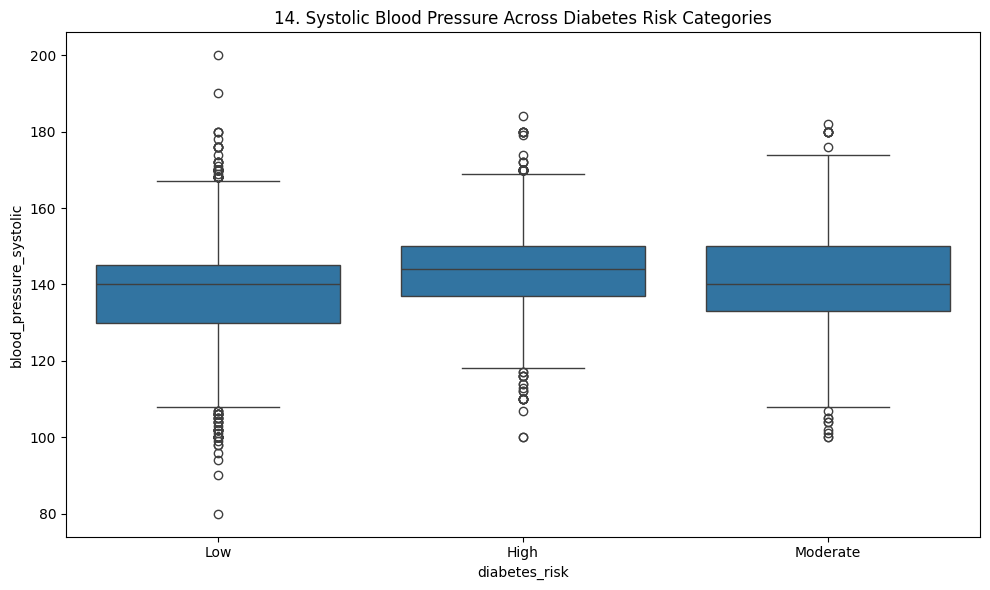

In [96]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='diabetes_risk', y='blood_pressure_systolic')
plt.title(f'{plot_no}. Systolic Blood Pressure Across Diabetes Risk Categories')
show_fig()
plot_no += 1

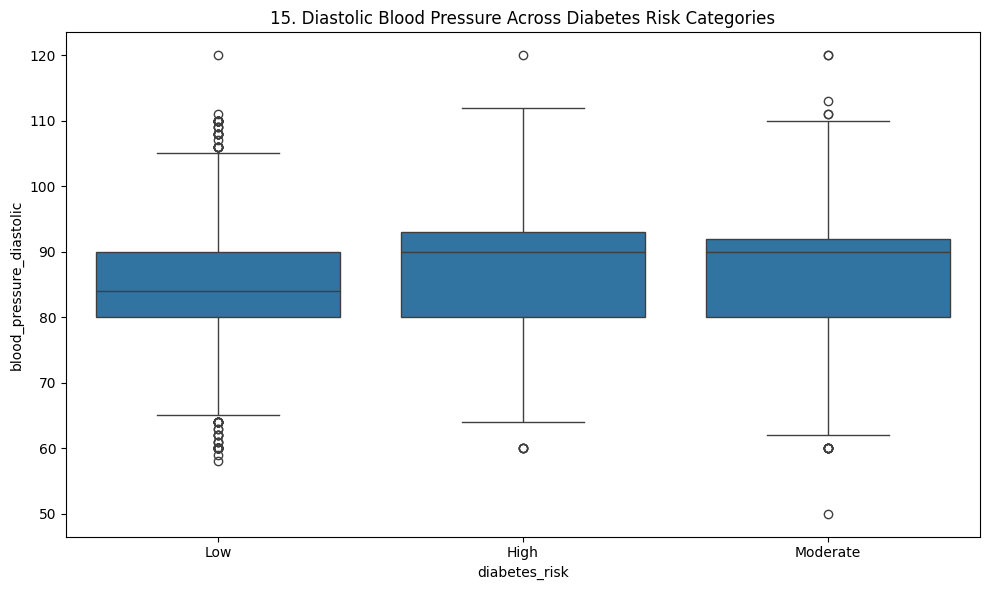

In [97]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='diabetes_risk', y='blood_pressure_diastolic')
plt.title(f'{plot_no}. Diastolic Blood Pressure Across Diabetes Risk Categories')
show_fig()
plot_no += 1

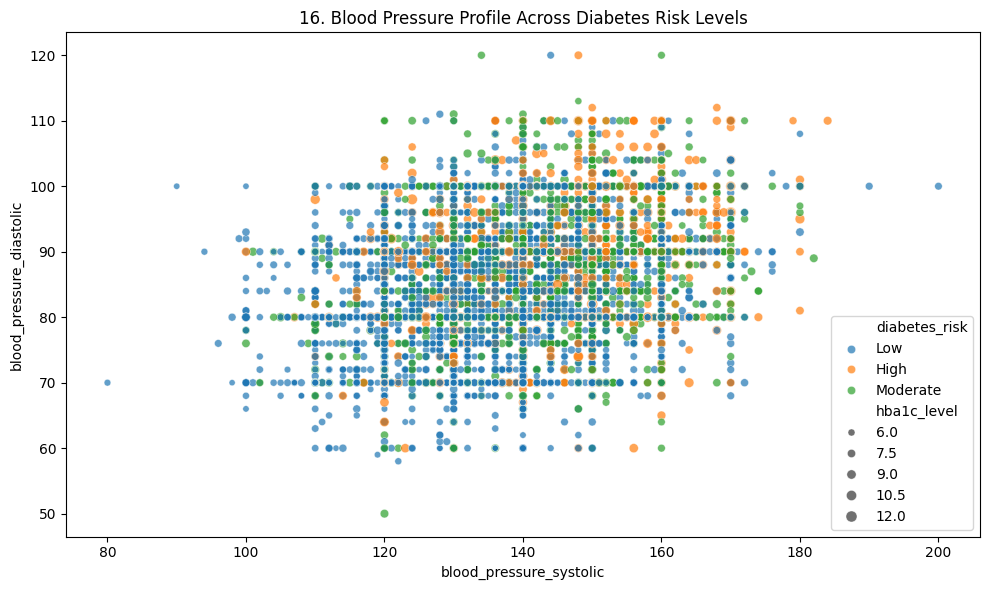

In [98]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='blood_pressure_systolic', y='blood_pressure_diastolic', hue='diabetes_risk', size='hba1c_level', alpha=0.7)
plt.title(f'{plot_no}. Blood Pressure Profile Across Diabetes Risk Levels')
show_fig()
plot_no += 1

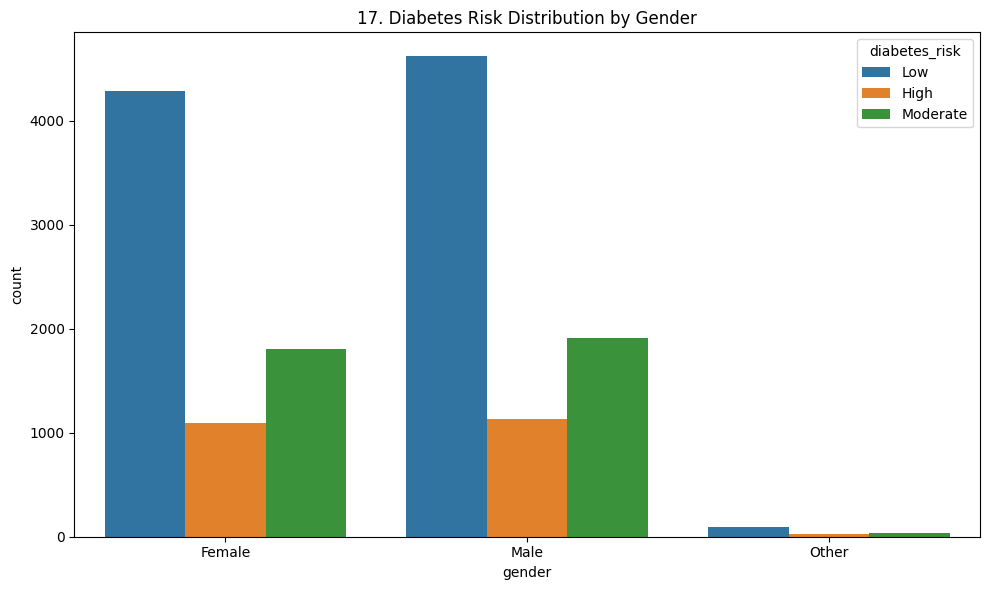

In [99]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='gender', hue='diabetes_risk')
plt.title(f'{plot_no}. Diabetes Risk Distribution by Gender')
show_fig()
plot_no += 1

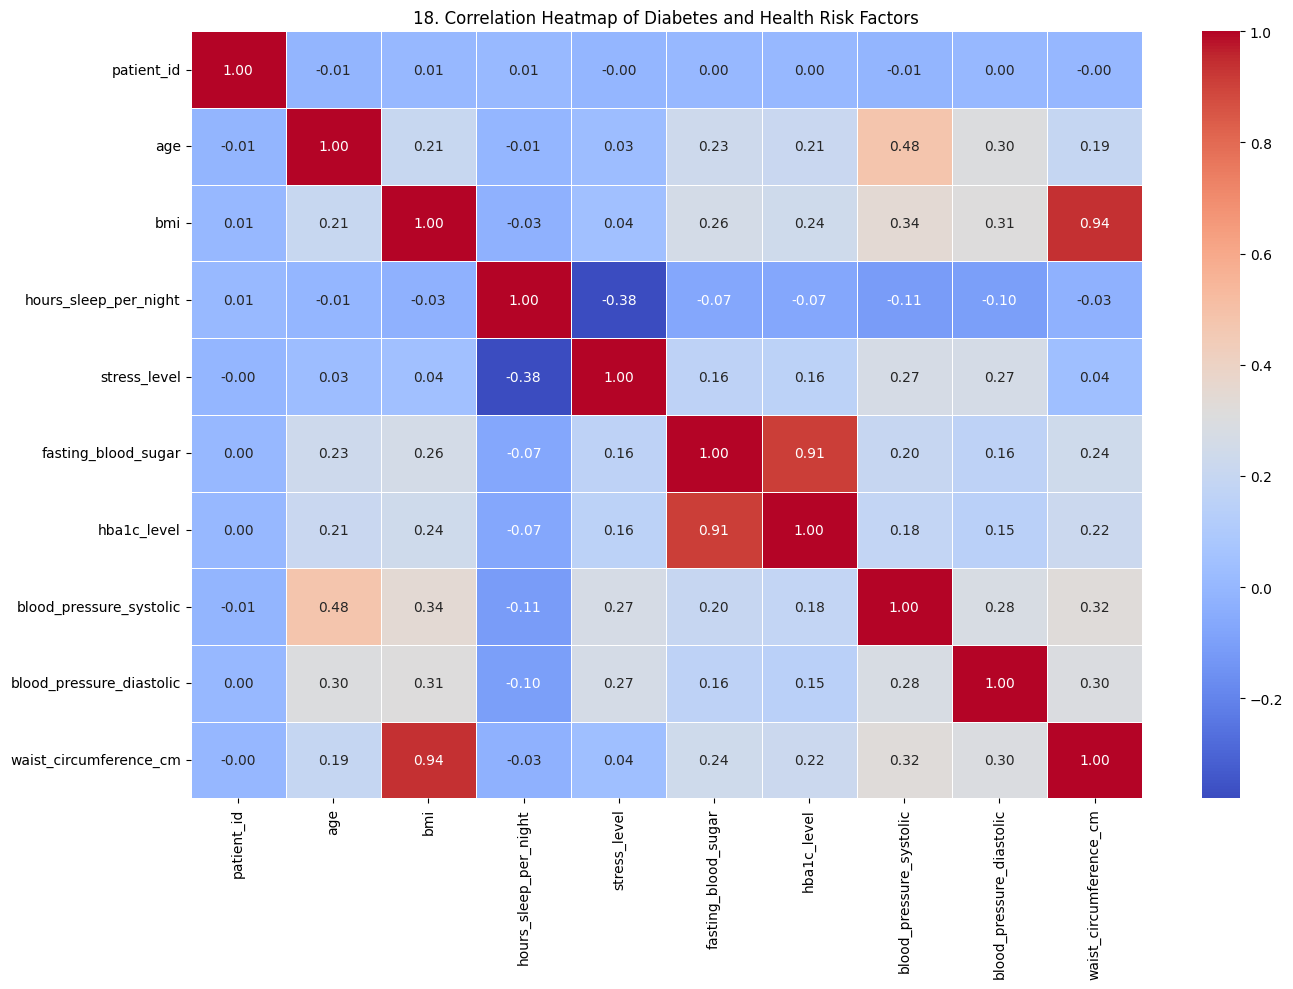

In [100]:
corr = df.select_dtypes(include='number').corr()

fig = plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title(f'{plot_no}. Correlation Heatmap of Diabetes and Health Risk Factors')
show_fig()
plot_no += 1

# Model Training

## Select features and target

In [101]:
X = df.drop(columns=['patient_id', 'diabetes_risk'])
y = df['diabetes_risk']

## Convert categorical features into numerical features

In [102]:
X = pd.get_dummies(X, drop_first=True)

## Split the dataset

In [103]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Scale the features

In [104]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Train Logistic Regression

In [105]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

## Make predictions

In [106]:
y_pred = model.predict(X_test)

## Print accuracy

In [107]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", accuracy * 100)

Model Accuracy: 0.7956666666666666
Model Accuracy (%): 79.56666666666666


## Print classification report

In [108]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

        High       0.82      0.73      0.77       450
         Low       0.86      0.91      0.88      1800
    Moderate       0.61      0.56      0.58       750

    accuracy                           0.80      3000
   macro avg       0.76      0.73      0.75      3000
weighted avg       0.79      0.80      0.79      3000



## Plot confusion matrix

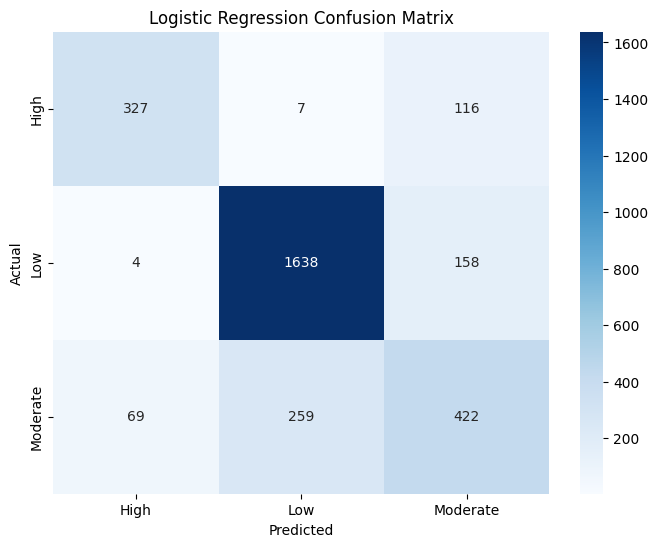

In [109]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()